In [5]:
from OptimalBattery import simulate as sim
import numpy as np
import matplotlib.pyplot as plt
import HierarchBayesParcel.evaluation as ev
import torch as pt
import OptimalBattery.util as ut
from numpy.linalg import eigh
from scipy.stats import pearsonr
import seaborn as sns
import os
import pandas as pd
import pickle
from PcmPy.sim import make_signal
from OptimalBattery.plot import plot_correlations

# start with a G structure

In [6]:
def custom_G(n_tasks=16, n_groups=4, group_size=4, target_corr=0.0004, variance_factors=[1.0, 0.75, 0.5, 0.25]):
    G = np.zeros((n_tasks, n_tasks))
    task_index = 0

    for group in range(n_groups):
        variances = variance_factors

        # Compute covariances based on desired correlation
        covariances = target_corr * np.outer(variance_factors, variance_factors)
        np.fill_diagonal(covariances, variances)

        # Place the block into G
        start, end = task_index, task_index + group_size
        G[start:end, start:end] = covariances

        task_index += group_size

    return G

16


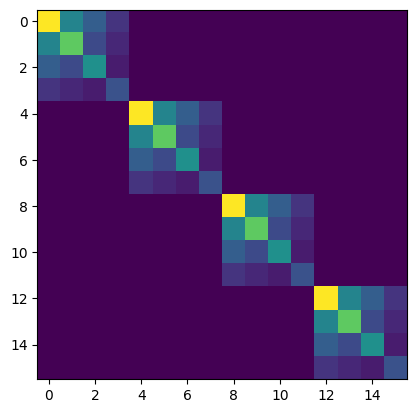

In [7]:
GL_custom = custom_G(n_tasks=16, n_groups=4, group_size=4, target_corr=0.6, variance_factors=[1.0, 0.75, 0.5, 0.25])
plt.imshow(GL_custom)

#print rank
print(np.linalg.matrix_rank(GL_custom))

# Get full V using PCA and then square root of eigenvalues

In [8]:
eigenvalues, eigenvectors = np.linalg.eigh(GL_custom)

16


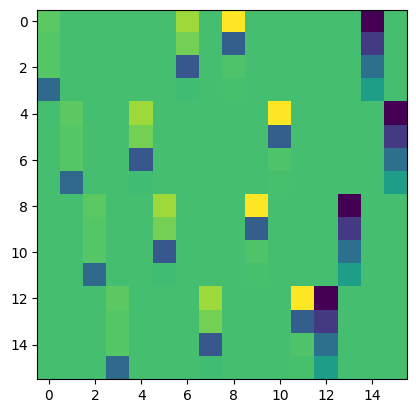

In [9]:
sqrt_eig = np.sqrt(eigenvalues)
Vlib = eigenvectors @ np.diag(sqrt_eig)
rank_v = np.linalg.matrix_rank(Vlib)

# normaliize V 
# V = V / np.sqrt(np.sum(V**2, axis=0))

plt.imshow(Vlib)
#print rank
print(np.linalg.matrix_rank(Vlib))



# Make Us random? 

In [10]:
n_parcels = 16  
n_voxels = 10000

In [11]:
U_true = np.zeros((n_parcels, n_voxels))
for i in range(n_parcels):
    U_true[i, :] = np.random.randn(n_voxels)

    # Normalize each parcel so that they have equal contribution?
    U_true[i, :] /= np.linalg.norm(U_true[i, :])

print(np.linalg.matrix_rank(U_true))

16


# Get ground truth data

In [12]:
Ylib = Vlib @ U_true
Ylib_noisy = Ylib + np.random.normal(0, 0.01, Ylib.shape)


16


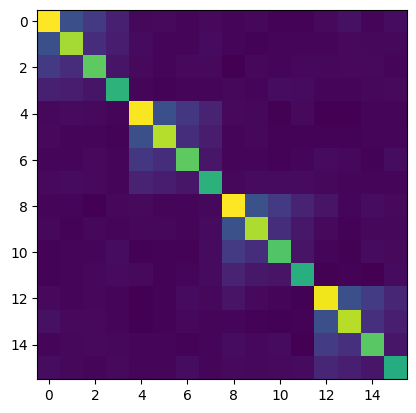

In [13]:
G_lib = Ylib_noisy @ Ylib_noisy.T
plt.imshow(G_lib)
print(np.linalg.matrix_rank(G_lib))

In [14]:
ytest = Ylib[4:8, :]
ytest_noisy = ytest+ np.random.normal(0, 0.01, ytest.shape)

vtest = Vlib[4:8, 4:6]


In [16]:
offsets = [1e-10,1e-8,1e-6,1e-4,1e-2,1,1e2,1e4,1e6,1e8,1e10]
D = ut.build_combinations(G_lib=G_lib, strategy='random',offs = offsets,n_iter=1000,n_tasks=7,seed=1)


building0


In [17]:
def evaluate_combinations(D, VLib,Ylib,U_true, ytest, vtest):
    D['combination_tuple'] = D['combination'].apply(lambda x: tuple(x))
    unique_combinations = D['combination_tuple'].unique()
    
    # Initialize a dictionary to store cos_HBP for each unique combination
    mse_ols_dict = {}
    cos_ols_dict = {}
    
    # Loop over each unique combination
    for i, comb_tuple in enumerate(unique_combinations):
        if i % 100 == 0:
            print(f"Processing combination: {i}")
        
        # Get the task subset indices and corresponding data
        task_subset_indices = list(comb_tuple)
        V_subset = VLib[task_subset_indices, 4:6]
        V_subset = V_subset - np.mean(V_subset, axis=0)

        y_subset = Ylib[task_subset_indices, :]
        y_subset = y_subset - np.mean(y_subset, axis=0)

        U_hat_ols = sim.estimate_Us_ols(y_subset, V_subset)
        mse_ols = sim.U_MSE(U_true[4:6,:], U_hat_ols)
        
        U_hat_ols = pt.tensor(U_hat_ols,dtype=pt.float32)
        ytest = pt.tensor(ytest,dtype=pt.float32)
        vtest = pt.tensor(vtest,dtype=pt.float32)
        cos_ols = ev.coserr(ytest,vtest,U_hat_ols).mean().cpu().numpy()
        cos_ols = cos_ols.item()
        
        # Store the result in the dictionary
        mse_ols_dict[comb_tuple] = mse_ols
        cos_ols_dict[comb_tuple] = cos_ols
    
    # Map the computed cos_HBP values back to the DataFrame
    D['mse_ols'] = D['combination_tuple'].map(mse_ols_dict)
    D['cos_ols'] = D['combination_tuple'].map(cos_ols_dict)
    
    return D

In [18]:
D = evaluate_combinations(D, VLib=Vlib, Ylib=Ylib_noisy, U_true=U_true, ytest=ytest_noisy, vtest=vtest)

Processing combination: 0


LinAlgError: Singular matrix

KeyError: 'mse_ols'

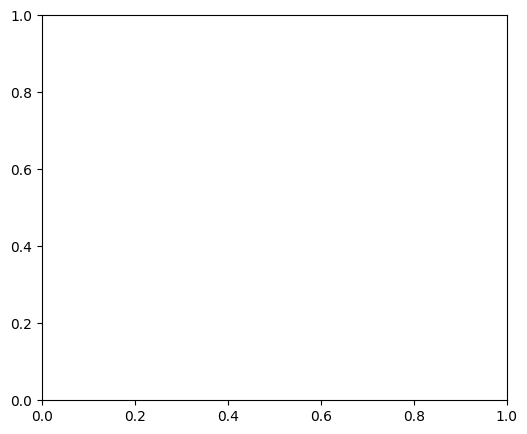

In [19]:
plot_correlations(D, ['mse_ols'],['cos_ols'])